# Example loading a batch of data using the PyTorch dataloaders

Package requirements:
- pytorch
- numpy
- pandas
- tqdm
- h5py
- matplotlib
- xarray
- cartopy
- skyfield

*Google Colaboratory will already have these packages installed, except for cartopy*

### Imports

In [1]:
!pip install cartopy
!pip install awscli

# Imports
import os
import torch
import pickle
import hashlib
import tarfile
import datetime
import warnings
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt

from tqdm import tqdm
from glob import glob
from io import BytesIO
from functools import lru_cache
from torch.utils.data import Dataset

### Define some necessary functions and dataset classes

Functions

In [2]:
# SDOML-lite: 2010-05-13T00:00:00 - 2024-07-27T00:00:00
# SDOML: 2010-05-13T00:12:00 - 2018-08-17T04:48:00

# NOAA Space Weather Scales
# Geomagnetic Storms
# https://www.swpc.noaa.gov/noaa-scales-explanation
#
# G0: Unsettled (Kp < 4)
# G1: Minor (5 <= Kp < 6)
# G2: Moderate (6 <= Kp < 7)
# G3: Strong (7 <= Kp < 8)
# G4: Severe (8 <= Kp < 9)
# G5: Extreme (Kp >= 9)

# The Mestici Scale
# G1H9: G1 and higher geomagnetic storms, with a duration of at least 9 hours
# G2H9: G2 and higher geomagnetic storms, with a duration of at least 9 hours
# G3H9: G3 and higher geomagnetic storms, with a duration of at least 9 hours
# G4H9: G4 and higher geomagnetic storms, with a duration of at least 9 hours
# G5H9: G5 and higher geomagnetic storms, with a duration of at least 9 hours
# The events are based on the Mestici Scale, which is a measure of geomagnetic storm activity.


class EventCatalog():
    def __init__(self, catalog=None, events_csv_file_name=None):
        if catalog is not None:
            self.catalog = catalog
        else:
            events_df = pd.read_csv(events_csv_file_name)

            # rename column Event_Index to prefix
            events_df.rename(columns={'Event_Index': 'prefix'}, inplace=True)
            events_df.rename(columns={'Start': 'start', 'End': 'end', 'Max_Kp': 'max_kp'}, inplace=True)

            # Replace the End column with new values computed from the start and Duration_hours column
            events_df['end'] = pd.to_datetime(events_df['start'], format='%Y-%m-%d %H:%M:%S') + pd.to_timedelta(events_df['Duration_hours'], unit='h')

            # sort by start
            events_df = events_df.sort_values(by=['prefix', 'start'])

            format = '%Y-%m-%d %H:%M:%S'
            events_df['date_start'] = pd.to_datetime(events_df['start'], format=format)
            events_df['date_end'] = pd.to_datetime(events_df['end'], format=format)
            events_df['duration'] = events_df['date_end'] - events_df['date_start']

            # Round down date_start to nearest :00, :15, :30, :45
            events_df['date_start'] = events_df['date_start'].dt.floor('15min')

            # count the number of times each unique prefix appears
            events_df['event_id'] = events_df.groupby('prefix').cumcount() + 1

            self.catalog = {}
            for prefix in events_df['prefix'].unique():
                events_with_prefix = events_df[events_df['prefix'] == prefix]
                num_events = len(events_with_prefix)
                for i in range(num_events):
                    event = events_with_prefix.iloc[i]
                    # event_id = prefix + '-' + str(i+1).zfill(len(str(num_events)))
                    date_start = event['date_start'].isoformat()
                    date_end = event['date_end'].isoformat()
                    duration = event['duration']
                    # sequence_length is the duration in units of time step (15 minutes)
                    time_steps = int(duration.total_seconds() / (15*60))
                    if time_steps > 0:
                        event_id = prefix + '-' + event['date_start'].strftime("%Y%m%d%H%M")
                        max_kp = event['max_kp']
                        self.catalog[event_id] = {
                            'date_start': date_start,
                            'date_end': date_end,
                            'duration': duration,
                            'max_kp': max_kp,
                            'time_steps': time_steps
                        }

    def __len__(self):
        return len(self.catalog)

    def __getitem__(self, key):
        return self.catalog[key]

    def __contains__(self, item):
        return item in self.catalog

    def items(self):
        return self.catalog.items()

    def keys(self):
        return self.catalog.keys()

    def filter(self, prefix=None, date_start=None, date_end=None, max_kp_min=None, max_kp_max=None, time_steps_min=None, time_steps_max=None):
        filtered = self.catalog
        if prefix:
            filtered = {k: v for k, v in filtered.items() if k.startswith(prefix)}
        if date_start:
            date_start = pd.to_datetime(date_start)
            filtered = {k: v for k, v in filtered.items() if pd.to_datetime(v['date_start']) >= date_start}
        if date_end:
            date_end = pd.to_datetime(date_end)
            filtered = {k: v for k, v in filtered.items() if pd.to_datetime(v['date_end']) <= date_end}
        if max_kp_min is not None:
            filtered = {k: v for k, v in filtered.items() if v['max_kp'] >= max_kp_min}
        if max_kp_max is not None:
            filtered = {k: v for k, v in filtered.items() if v['max_kp'] <= max_kp_max}
        if time_steps_min is not None:
            filtered = {k: v for k, v in filtered.items() if v['time_steps'] >= time_steps_min}
        if time_steps_max is not None:
            filtered = {k: v for k, v in filtered.items() if v['time_steps'] <= time_steps_max}
        return EventCatalog(filtered)

    # remove overlapping events
    def unique(self):
        unique_catalog = {}
        for event_id, details in self.catalog.items():
            if not any(details['date_start'] < other['date_end'] and details['date_end'] > other['date_start'] for other in unique_catalog.values()):
                unique_catalog[event_id] = details
        return EventCatalog(unique_catalog)

    # random subsample, sample without replacement
    def sample(self, n):
        if n > len(self.catalog):
            warn(f"Requested sample size {n} is larger than the catalog size {len(self.catalog)}. Returning the full catalog.")
            return self
        sampled_keys = np.random.choice(list(self.catalog.keys()), size=n, replace=False)
        sampled_catalog = {k: self.catalog[k] for k in sampled_keys}
        return EventCatalog(sampled_catalog)

    def exclude(self, date_exclusions):
        # date_exclusions is a list of (exclusion_start, exclusion_end) tuples where exclusion_start and exclusion_end are datetime objects
        filtered = self.catalog
        for exclusion_start, exclusion_end in date_exclusions:
            filtered = {k: v for k, v in filtered.items() if not (pd.to_datetime(v['date_start']) < exclusion_end and pd.to_datetime(v['date_end']) > exclusion_start)}
        return EventCatalog(filtered)

    def exclude_context_overlap(self, date_exclusions, context_window_minutes):
        """
        Exclude events whose context window would overlap with any excluded date range.

        Args:
            date_exclusions: List of (exclusion_start, exclusion_end) tuples where both are datetime objects
            context_window_minutes: Number of minutes of context data needed before event start

        Returns:
            EventCatalog: New catalog with events filtered out if their context window overlaps with exclusions
        """
        import datetime
        filtered = {}

        for event_id, event in self.catalog.items():
            event_start = pd.to_datetime(event['date_start'])
            event_end = pd.to_datetime(event['date_end'])
            # Calculate context window start time
            event_context_start = event_start - datetime.timedelta(minutes=context_window_minutes)

            # Check if [event_context_start, event_end] overlaps with any excluded range
            overlaps_with_exclusion = False
            for exclusion_start, exclusion_end in date_exclusions:
                # Two ranges [A1, A2] and [B1, B2] overlap if A1 < B2 AND A2 > B1
                if event_context_start < exclusion_end and event_end > exclusion_start:
                    overlaps_with_exclusion = True
                    break

            if not overlaps_with_exclusion:
                filtered[event_id] = event

        return EventCatalog(filtered)

    def ids(self):
        return list(self.catalog.keys())

In [3]:
# Utility function to stack features as channels for input to a model
def stack_as_channels(features, image_size=(180,360)):
    if not isinstance(features, list) and not isinstance(features, tuple):
        raise ValueError('Expecting a list or tuple of features')
    c = []
    for f in features:
        if not isinstance(f, torch.Tensor):
            f = torch.tensor(f, dtype=torch.float32)
        if f.ndim == 0:
            f = f.expand(image_size)
            f = f.unsqueeze(0)
        elif f.ndim == 1:
            f = f.view(-1, 1, 1)
            f = f.expand((-1,) + image_size)
        elif f.shape == image_size:
            f = f.unsqueeze(0)  # add channel dimension
        else:
            raise ValueError('Expecting 0d or 1d features, or 2d features with shape equal to image_size')
        c.append(f)
    c = torch.cat(c, dim=0)
    return c


# Yeo-Johnson transformation
# Based on https://github.com/scikit-learn/scikit-learn/blob/c5497b7f7eacfaff061cf68e09bcd48aa93d4d6b/sklearn/preprocessing/_data.py#L3480
def yeojohnson(X, lambdas):
    if X.shape != lambdas.shape:
        raise ValueError("X and lambdas must have the same shape.")
    if X.ndim != 1:
        raise ValueError("X must be a 1D tensor.")

    # Ensure that no lambdas are 0 or 2 to avoid division by zero
    if torch.isclose(lambdas, torch.zeros_like(lambdas), atol=1e-8).any() or torch.isclose(lambdas, torch.tensor(2.0, dtype=lambdas.dtype, device=lambdas.device), atol=1e-8).any():
        raise ValueError("Lambdas must not contain 0 or 2 to avoid division by zero.")

    out = torch.zeros_like(X)
    pos = X >= 0  # binary mask

    # CAUTION: this assumes a lambda will never be 0 or 2
    out[pos] = (torch.pow(X[pos] + 1, lambdas[pos]) - 1) / lambdas[pos]
    out[~pos] = -(torch.pow(-X[~pos] + 1, 2 - lambdas[~pos]) - 1) / (2 - lambdas[~pos])
    return out


# Yeo-Johnson inverse transformation
# Based on https://github.com/scikit-learn/scikit-learn/blob/c5497b7f7eacfaff061cf68e09bcd48aa93d4d6b/sklearn/preprocessing/_data.py#L3424C1-L3431C41
def yeojhonson_inverse(X, lambdas):
    if X.shape != lambdas.shape:
        raise ValueError("X and lambdas must have the same shape.")
    if X.ndim != 1:
        raise ValueError("X must be a 1D tensor.")
    X_original = torch.zeros_like(X)
    pos = X >= 0

    # Ensure that no lambdas are 0 or 2 to avoid division by zero
    if torch.isclose(lambdas, torch.zeros_like(lambdas), atol=1e-8).any() or torch.isclose(lambdas, torch.tensor(2.0, dtype=lambdas.dtype, device=lambdas.device), atol=1e-8).any():
        raise ValueError("Lambdas must not contain 0 or 2 to avoid division by zero.")


    # CAUTION: this assumes a lambda will never be 0 or 2
    X_original[pos] = (X[pos] * lambdas[pos] + 1) ** (1 / lambdas[pos]) - 1
    X_original[~pos] = 1 - (-(2 - lambdas[~pos]) * X[~pos] + 1) ** (1 / (2 - lambdas[~pos]))

    return X_original

Dataset classes

In [4]:
# Pandas Dataset (for Omniweb and Celestrak and SET)

class PandasDataset(Dataset):
    def __init__(self, name, data_frame, column, delta_minutes=15, date_start=None, date_end=None, normalize=True, rewind_minutes=15, date_exclusions=None, return_as_image_size=None):
        self.name = name
        self.data = data_frame
        self.column = column
        self.delta_minutes = delta_minutes

        if return_as_image_size is not None:
            if not isinstance(return_as_image_size, tuple):
                raise ValueError('return_as_image_size must be a tuple, e.g. (180, 360)')
            if len(return_as_image_size) != 2:
                raise ValueError('return_as_image_size must be a tuple of length 2, e.g. (180, 360)')

        self.return_as_image_size = return_as_image_size

        print('Delta minutes         : {:,}'.format(self.delta_minutes))
        self.normalize = normalize
        print('Normalize             : {}'.format(self.normalize))
        self.rewind_minutes = rewind_minutes
        print('Rewind minutes        : {:,}'.format(self.rewind_minutes))
        print('Columns               : {}'.format(self.column))
        print('Return as image size  : {}'.format(self.return_as_image_size))
        print('Rows before processing: {:,}'.format(len(self.data)))

        self.data[column] = self.data[column].astype(np.float32)
        self.data.replace([np.inf, -np.inf], np.nan, inplace=True)

        self.data = self.data.dropna() # This drops ~10% of omniweb, a bit wasteful as it drops entire row at a time but not too bad
        # Get dates available

        # Explicitly create a copy after dropna() to avoid SettingWithCopyWarning
        self.data = self.data.copy()

        self.data['Datetime'] = pd.to_datetime(self.data['Datetime']) # this line wasnt present previously but is necessary if the col contains strings instead of pandas timestamps for the date.to_pydatetime() to run as expected
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")  # Ignore all warnings
            self.dates = self.data['Datetime'].dt.to_pydatetime() # super slow!

        self.dates_set = set(self.dates)
        self.date_start = self.dates[0]
        self.date_end = self.dates[-1]

        # Adjust dates available
        if date_start is not None:
            if isinstance(date_start, str):
                date_start = datetime.datetime.fromisoformat(date_start)
            if (date_start >= self.date_start) and (date_start < self.date_end):
                self.date_start = date_start
            else:
                print('Start date out of range, using default')
        if date_end is not None:
            if isinstance(date_end, str):
                date_end = datetime.datetime.fromisoformat(date_end)
            if (date_end > self.date_start) and (date_end <= self.date_end):
                self.date_end = date_end
            else:
                print('End date out of range, using default')

        # if not 'CRaTER' in self.name: # Very bad hack, need to fix this for CRaTER # NOTE CRaTER Not relevant for ionosphere datasets
        # if the date of the first row of data after self.date_start does not end in minutes :00, :self.delta_minutes, :self.delta_minutes*2, ..., move forward to the next minute that does
        # Note: won't make sense if data has irregular cadences (i.e. this only adjusts the start date to the next available time that fits the cadence, it does not fill in missing data)
        time_out = 1000
        while True:
            first_row = self.data[self.data['Datetime'] >= self.date_start].iloc[0]
            first_row_date = first_row['Datetime']
            if first_row_date.minute % self.delta_minutes != 0:
                print('Adjust startdate(old): {}'.format(first_row_date))
                first_row_date = first_row_date + datetime.timedelta(minutes=self.delta_minutes - (first_row_date.minute % self.delta_minutes))
                print('Adjust startdate(new): {}'.format(first_row_date))
                self.date_start = first_row_date
                time_out -= 1
                if time_out == 0:
                    raise RuntimeError('Time out in adjusting start date for {}'.format(self.name))
            else:
                break

        # Filter out dates outside the range
        self.data = self.data[(self.data['Datetime'] >=self.date_start) & (self.data['Datetime'] <=self.date_end)]

        # Filter out dates within date_exclusions
        self.date_exclusions = date_exclusions
        if self.date_exclusions is not None:
            print('Date exclusions:')
            for exclusion_date_start, exclusion_date_end in self.date_exclusions:
                print('  {} - {}'.format(exclusion_date_start, exclusion_date_end))
                self.data = self.data[~self.data['Datetime'].between(exclusion_date_start, exclusion_date_end)]

        # Get dates available (redo to make sure things match up)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")  # Ignore all warnings
            self.dates = self.data['Datetime'].dt.to_pydatetime() # super slow!

        self.dates_set = set(self.dates)
        self.date_start = self.dates[0]
        self.date_end = self.dates[-1]
        print('Start date            : {}'.format(self.date_start))
        print('End date              : {}'.format(self.date_end))

        print('i')

        print('Rows after processing : {:,}'.format(len(self.data)))
        # self.data.set_index("Datetime", inplace=True) # sets the indexing to be done with datetime

        # print('Memory usage          : {:,} bytes'.format(self.data.memory_usage(deep=True).sum()))



    def normalize_data(self, data):
        raise NotImplementedError('normalize_data not implemented')

    def unnormalize_data(self, data):
        raise NotImplementedError('unnormalize_data not implemented')

    def __repr__(self):
        return '{} ({} - {})'.format(self.name, self.date_start, self.date_end)

    def __len__(self):
        return len(self.data)


    def __getitem__(self, index):
        if isinstance(index, datetime.datetime):
            date = index
        elif isinstance(index, str):
            date = datetime.datetime.fromisoformat(index)
        elif isinstance(index, int): # THIS WILL CAUSE ERRORS WHEN DEALING WITH MULTPLIE DATASETS
            date = self.data.iloc[index]['Datetime']
            # warn("Should not index dataset by int if aligning multiple datasets, this is error prone if datasets have holes.")
            # Gunes: I think the behavior here is fine, it's just an index to iterate over the number of rows in the dataset, whatever they may be. A problem can happen if someone manually tries to align the datasets by integer indices, which we shouldn't do anyway.
        else:
            raise ValueError('Expecting index to be int, datetime.datetime, or str (in the format of 2022-11-01T00:01:00)')
        data = self.get_data(date)
        return data, date.isoformat()

    def get_data(self, date):
        # if date < self.date_start or date > self.date_end:
        #     raise ValueError('Date ({}) out of range for RadLab ({}; {} - {})'.format(date, self.instrument, self.date_start, self.date_end))

        if date not in self.dates_set:
            print('{} date not found: {}'.format(self.name, date))
            # find the most recent date available before date, in pandas dataframe self.data
            dates_available = self.data[self.data['Datetime'] < date]
            if len(dates_available) > 0:
                date_previous = dates_available.iloc[-1]['Datetime']
                if date - date_previous < datetime.timedelta(minutes=self.rewind_minutes):
                    print('{} rewinding to  : {}'.format(self.name, date_previous))
                    data = self.data[self.data['Datetime'] == date_previous][self.column]
                else:
                    return None
            else:
                return None
        else:
            data = self.data[self.data['Datetime'] == date][self.column]
            if len(data) == 0:
                raise RuntimeError('Should not happen')
        data = torch.tensor(data.values[0], dtype=torch.float32)
        if self.normalize:
            data = self.normalize_data(data)

        if self.return_as_image_size is not None:
            data = data.view(data.shape + (1, 1)).expand(-1, *self.return_as_image_size)

        return data

    def get_series(self, date_start, date_end, delta_minutes=None, omit_missing=True):
        if delta_minutes is None:
            delta_minutes = self.delta_minutes
        dates = []
        values = []
        date = date_start
        while date <= date_end:
            value = self.get_data(date)
            value_available = True
            if value is None:
                if omit_missing:
                    value_available = False
                else:
                    value = torch.tensor(float('nan'))
            if value_available:
                dates.append(date)
                values.append(value)
            date += datetime.timedelta(minutes=delta_minutes)
        if len(dates) == 0:
            # raise ValueError('{} no data found between {} and {}'.format(self.name, self.instrument, date_start, date_end))
            return None, None
        values = torch.stack(values).flatten()
        return dates, values

    @staticmethod
    def fill_to_cadence(df, delta_minutes=15, rewind_minutes=50):
        df["Datetime"] = pd.to_datetime(df["Datetime"]) # strs to convert to datetime objs

        df = df.sort_values("Datetime").reset_index(drop=True) # to make sure df is ordered properly
        filled_rows = []
        rewind_minutes = datetime.timedelta(minutes=rewind_minutes)

        for i in tqdm(range(1, len(df)), desc='Filling to cadence', unit='row'):
            prev_row = df.iloc[i - 1]
            curr_row = df.iloc[i]

            t0 = prev_row["Datetime"]
            t1 = curr_row["Datetime"]

            if (t1 - t0) > rewind_minutes:  # no infilling if gap larger than rewind time
                filled_rows.append(prev_row)
                continue
            # Generate target timestamps at delta_minutes cadence
            # First aligned timestamp after t0
            remainder = (t0.minute % delta_minutes)
            correction = datetime.timedelta(minutes=(delta_minutes - remainder) % delta_minutes)
            aligned_start = (t0.replace(second=0, microsecond=0) + correction)

            # Create date range between aligned_start and t1
            timestamps = pd.date_range(
                start=aligned_start,
                end=t1,
                freq=f'{delta_minutes}min'
            )

            # Add the original row
            filled_rows.append(prev_row)

            # For each interpolated timestamp, duplicate previous row and set new time
            for ts in timestamps:
                if ts == t0: continue # already added row corresponding to t0 (prev_row)
                if ts < t1:  # Only fill between, not including t1
                    new_row = prev_row.copy()
                    new_row["Datetime"] = ts
                    filled_rows.append(new_row)

        # Append the final row
        filled_rows.append(df.iloc[-1])
        # df_filled
        return pd.DataFrame(filled_rows).reset_index(drop=True)

In [5]:
# Cached Datalaoder (for faster loading if training/performing inference on the same set of data)

class CachedDataset(Dataset):
    """A wrapper dataset that pre-loads and caches all items from another dataset into memory."""
    def __init__(self, dataset):
        self.dataset = dataset
        print("Pre-loading and caching dataset into memory...")
        self.data = [dataset[i] for i in tqdm(range(len(dataset)), desc="Caching")]
        print("Caching complete.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [6]:
# SET Dataset

# Space Environment Technologies (SET) dataset
# https://setinc.com/space-environment-technologies/


set_all_columns = ['space_environment_technologies__f107_obs__',
                    'space_environment_technologies__f107_average__',
                    'space_environment_technologies__s107_obs__',
                    'space_environment_technologies__s107_average__',
                    'space_environment_technologies__m107_obs__',
                    'space_environment_technologies__m107_average__',
                    'space_environment_technologies__y107_obs__',
                    'space_environment_technologies__y107_average__',
                    'JB08__d_st_dt__[K]']

set_yeojohnson_lambdas = {'space_environment_technologies__f107_obs__': -0.763051477303,
                                 'space_environment_technologies__f107_average__': -0.551868341046,
                                 'space_environment_technologies__s107_obs__': 0.751363821795,
                                 'space_environment_technologies__s107_average__': 0.830731313661,
                                 'space_environment_technologies__m107_obs__': -0.407092166244,
                                 'space_environment_technologies__m107_average__': -0.305245272819,
                                 'space_environment_technologies__y107_obs__': 0.381375169921,
                                 'space_environment_technologies__y107_average__': 0.409993940749,
                                 'JB08__d_st_dt__[K]': 0.484842249526}

set_mean_of_yeojohnson = {'space_environment_technologies__f107_obs__': 1.272172135660,
                                      'space_environment_technologies__f107_average__': 1.672840949524,
                                      'space_environment_technologies__s107_obs__': 42.899690917474,
                                      'space_environment_technologies__s107_average__': 56.218558006899,
                                      'space_environment_technologies__m107_obs__': 2.086639724956,
                                      'space_environment_technologies__m107_average__': 2.486937790517,
                                      'space_environment_technologies__y107_obs__': 13.190408983866,
                                      'space_environment_technologies__y107_average__': 14.416800581748,
                                      'JB08__d_st_dt__[K]': 11.168264154109}

set_std_of_yeojohnson = {'space_environment_technologies__f107_obs__': 0.009865107914,
                                    'space_environment_technologies__f107_average__': 0.025485688944,
                                    'space_environment_technologies__s107_obs__': 14.521479851065,
                                    'space_environment_technologies__s107_average__': 21.361781197713,
                                    'space_environment_technologies__m107_obs__': 0.053843493314,
                                    'space_environment_technologies__m107_average__': 0.083871042526,
                                    'space_environment_technologies__y107_obs__': 2.167670990277,
                                    'space_environment_technologies__y107_average__': 2.403143006206,
                                    'JB08__d_st_dt__[K]': 5.629712229161}

set_all_columns_yeojohnson_lambdas = torch.tensor([set_yeojohnson_lambdas[col] for col in set_all_columns], dtype=torch.float32)
set_all_columns_mean_of_yeojohnson = torch.tensor([set_mean_of_yeojohnson[col] for col in set_all_columns], dtype=torch.float32)
set_all_columns_std_of_yeojohnson = torch.tensor([set_std_of_yeojohnson[col] for col in set_all_columns], dtype=torch.float32)

# ionosphere-data/set/karman-2025_data_sw_data_set_sw.csv
class SET(PandasDataset):
    def __init__(self, file_name, date_start=None, date_end=None, normalize=True, rewind_minutes=1440, date_exclusions=None, column=set_all_columns, delta_minutes=15, return_as_image_size=None): # 50 minutes rewind defualt
        print('\nSpace Environment Technologies')
        print('File           : {}'.format(file_name))

        data = pd.read_csv(file_name)

        # rename all__dates_datetime__ to Datetime
        data.rename(columns={'all__dates_datetime__': 'Datetime'}, inplace=True)
        # convert Datetime to datetime
        data['Datetime'] = pd.to_datetime(data['Datetime'])
        data = data.copy()

        self.column = column

        stem = Path(file_name).stem
        new_stem = f"{stem}_deltamin_{delta_minutes}_rewind_{rewind_minutes}"
        cadence_matched_fname = Path(file_name).with_stem(new_stem)
        if cadence_matched_fname.exists():
            print(f"Using cached file: {cadence_matched_fname}")
            data = pd.read_csv(cadence_matched_fname)
        else:
            data = PandasDataset.fill_to_cadence(data, delta_minutes=delta_minutes, rewind_minutes=rewind_minutes)
            data.to_csv(cadence_matched_fname) # the fill to cadence can take a while, so cache file

        super().__init__('Space Environment Technologies', data, self.column, delta_minutes, date_start, date_end, normalize, rewind_minutes, date_exclusions, return_as_image_size)

    def normalize_data(self, data):
        if self.column == set_all_columns:
            data = yeojohnson(data, set_all_columns_yeojohnson_lambdas)
            data = (data - set_all_columns_mean_of_yeojohnson) / set_all_columns_std_of_yeojohnson
        else:
            lambdas = torch.tensor([set_yeojohnson_lambdas[col] for col in self.column], dtype=torch.float32)
            means = torch.tensor([set_mean_of_yeojohnson[col] for col in self.column], dtype=torch.float32)
            stds = torch.tensor([set_std_of_yeojohnson[col] for col in self.column], dtype=torch.float32)
            data = yeojohnson(data, lambdas)
            data = (data - means) / stds
        return data

    def unnormalize_data(self, data):
        if self.column == set_all_columns:
            data = data * set_all_columns_std_of_yeojohnson + set_all_columns_mean_of_yeojohnson
            data = yeojhonson_inverse(data, set_all_columns_yeojohnson_lambdas)
        else:
            lambdas = torch.tensor([set_yeojohnson_lambdas[col] for col in self.column], dtype=torch.float32)
            means = torch.tensor([set_mean_of_yeojohnson[col] for col in self.column], dtype=torch.float32)
            stds = torch.tensor([set_std_of_yeojohnson[col] for col in self.column], dtype=torch.float32)
            data = data * stds + means
            data = yeojhonson_inverse(data, lambdas)
        return data

In [7]:
# OMNIWeb Dataset

# Consider the following scaling, not currently implemented:
# omniweb__ae_index__[nT] clamp(0, inf) -> log1p -> z-score
# omniweb__al_index__[nT] -= 11 -> clamp(-inf, 0) -> neg -> log1p -> z-score (or maybe discard)
# omniweb__au_index__[nT] += 9 -> clamp(0, inf) -> log1p -> z-score (or maybe discard)
# omniweb__sym_d__[nT] z-score / yeo
# omniweb__sym_h__[nT] z-score x -> sign(x) * log1p(abs(x))
# omniweb__asy_d__[nT] z-score
# omniweb__bx_gse__[nT] z-score OK
# omniweb__by_gse__[nT] z-score OK
# omniweb__bz_gse__[nT] z-score OK
# omniweb__speed__[km/s] z-score
# omniweb__vx_velocity__[km/s] z-score
# omniweb__vy_velocity__[km/s] z-score
# omniweb__vz_velocity__[km/s] z-score

# mean and std for omni indices after yeo-johnson transformation
# omniweb__ae_index__[nT]: mean=3.382117810171, std=0.599638789174
# omniweb__al_index__[nT]: mean=-10.758787729440, std=7.776873220187
# omniweb__au_index__[nT]: mean=21.202255971757, std=17.939704773432
# omniweb__sym_d__[nT]: mean=-0.181702064224, std=2.998393072357
# omniweb__sym_h__[nT]: mean=-6.992693259217, std=12.396448647053
# omniweb__asy_d__[nT]: mean=2.628395773277, std=0.500936940952
# omniweb__speed__[km/s]: mean=0.962903675585, std=0.000397192623
# omniweb__vx_velocity__[km/s]: mean=-0.959153291778, std=0.000387756752
# omniweb__vy_velocity__[km/s]: mean=-1.591600332192, std=24.061675738624
# omniweb__vz_velocity__[km/s]: mean=-3.172566847907, std=21.392025871686
# omniweb__bx_gse__[nT]: mean=0.009877579877, std=3.477797581682
# omniweb__by_gse__[nT]: mean=-0.086797729712, std=4.004904143231
# omniweb__bz_gse__[nT]: mean=0.009738823405, std=3.251240498296

omniweb_all_columns = [
    'omniweb__ae_index__[nT]',
    'omniweb__al_index__[nT]',
    'omniweb__au_index__[nT]',
    'omniweb__sym_d__[nT]',
    'omniweb__sym_h__[nT]',
    'omniweb__asy_d__[nT]',
    'omniweb__bx_gse__[nT]',
    'omniweb__by_gse__[nT]',
    'omniweb__bz_gse__[nT]',
    'omniweb__speed__[km/s]',
    'omniweb__vx_velocity__[km/s]',
    'omniweb__vy_velocity__[km/s]',
    'omniweb__vz_velocity__[km/s]'
]

# lambda values for yeo-johnson transformation computed by Giacomo Acciarini, 5 Aug 2025
omniweb_yeojohnson_lambdas = {
    'omniweb__ae_index__[nT]': -0.127596533271,
    'omniweb__al_index__[nT]': 1.593553014366,
    'omniweb__au_index__[nT]': 0.694548772242,
    'omniweb__sym_d__[nT]': 1.023942223073,
    'omniweb__sym_h__[nT]': 1.150157823027,
    'omniweb__asy_d__[nT]': -0.044273161179,
    'omniweb__bx_gse__[nT]': 0.995147537010,
    'omniweb__by_gse__[nT]': 0.990598907069,
    'omniweb__bz_gse__[nT]': 1.007983055426,
    'omniweb__speed__[km/s]': -1.036437447980,
    'omniweb__vx_velocity__[km/s]': 3.040535004580,
    'omniweb__vy_velocity__[km/s]': 0.965800969635,
    'omniweb__vz_velocity__[km/s]': 0.998312073289
}

omniweb_mean_of_yeojohnson = {'omniweb__ae_index__[nT]': 3.382117810171,
                       'omniweb__al_index__[nT]': -10.758787729440,
                       'omniweb__au_index__[nT]': 21.202255971757,
                       'omniweb__sym_d__[nT]': -0.181702064224,
                       'omniweb__sym_h__[nT]': -6.992693259217,
                       'omniweb__asy_d__[nT]': 2.628395773277,
                       'omniweb__bx_gse__[nT]': 0.009877579877,
                       'omniweb__by_gse__[nT]': -0.086797729712,
                       'omniweb__bz_gse__[nT]': 0.009738823405,
                       'omniweb__speed__[km/s]': 0.962903675585,
                       'omniweb__vx_velocity__[km/s]': -0.959153291778,
                       'omniweb__vy_velocity__[km/s]': -1.591600332192,
                       'omniweb__vz_velocity__[km/s]': -3.172566847907}
omniweb_std_of_yeojohnson = {'omniweb__ae_index__[nT]': 0.599638789174,
                       'omniweb__al_index__[nT]': 7.776873220187,
                       'omniweb__au_index__[nT]': 17.939704773432,
                       'omniweb__sym_d__[nT]': 2.998393072357,
                       'omniweb__sym_h__[nT]': 12.396448647053,
                       'omniweb__asy_d__[nT]': 0.500936940952,
                       'omniweb__bx_gse__[nT]': 3.477797581682,
                       'omniweb__by_gse__[nT]': 4.004904143231,
                       'omniweb__bz_gse__[nT]': 3.251240498296,
                       'omniweb__speed__[km/s]': 0.000397192623,
                       'omniweb__vx_velocity__[km/s]': 0.000387756752,
                       'omniweb__vy_velocity__[km/s]': 24.061675738624,
                       'omniweb__vz_velocity__[km/s]': 21.392025871686}

omniweb_all_columns_yeojohnson_lambdas = torch.tensor([omniweb_yeojohnson_lambdas[col] for col in omniweb_all_columns], dtype=torch.float32)
omniweb_all_columns_mean_of_yeojohnson = torch.tensor([omniweb_mean_of_yeojohnson[col] for col in omniweb_yeojohnson_lambdas.keys()], dtype=torch.float32)
omniweb_all_columns_std_of_yeojohnson = torch.tensor([omniweb_std_of_yeojohnson[col] for col in omniweb_yeojohnson_lambdas.keys()], dtype=torch.float32)

# ionosphere-data/omniweb_karman_2025
class OMNIWeb(PandasDataset):
    def __init__(self, data_dir, date_start=None, date_end=None, normalize=True, rewind_minutes=50, date_exclusions=None, column=omniweb_all_columns, delta_minutes=15, return_as_image_size=None): # 50 minutes rewind defualt
        file_name_indices = os.path.join(data_dir, 'omniweb_indices_15min.csv')
        file_name_magnetic_field = os.path.join(data_dir, 'omniweb_magnetic_field_15min.csv')
        file_name_solar_wind = os.path.join(data_dir, 'omniweb_solar_wind_15min.csv')

        print('\nOMNIWeb')
        print('File indices           : {}'.format(file_name_indices))
        print('File magnetic field    : {}'.format(file_name_magnetic_field))
        print('File solar wind        : {}'.format(file_name_solar_wind))
        # delta_minutes = 1
        # delta_minutes = 15 # unclear what this is immediately, i think its supposed to match cadence but something to check out tmo

        data_indices = pd.read_csv(file_name_indices)
        data_magnetic_field = pd.read_csv(file_name_magnetic_field)
        data_solar_wind = pd.read_csv(file_name_solar_wind)

        #concat all columns to a single dataframe
        data = pd.concat([data_indices, data_magnetic_field, data_solar_wind], axis=1)

        # Remove duplicate columns (keep first occurrence)
        data = data.loc[:, ~data.columns.duplicated()]

        print('Data shape             : {}'.format(data.shape))
        print('Data columns           : {}'.format(data.columns.tolist()))

        # rename all__dates_datetime__ to Datetime
        data.rename(columns={'all__dates_datetime__': 'Datetime'}, inplace=True)
        # convert Datetime to datetime
        data['Datetime'] = pd.to_datetime(data['Datetime'])
        data = data.copy()

        self.column = column

        super().__init__('OMNIWeb', data, self.column, delta_minutes, date_start, date_end, normalize, rewind_minutes, date_exclusions, return_as_image_size)

    def normalize_data(self, data):
        if self.column == omniweb_all_columns:
            data = yeojohnson(data, omniweb_all_columns_yeojohnson_lambdas)
            data = (data - omniweb_all_columns_mean_of_yeojohnson) / omniweb_all_columns_std_of_yeojohnson
        else:
            lambdas = torch.tensor([omniweb_yeojohnson_lambdas[col] for col in self.column], dtype=torch.float32)
            means = torch.tensor([omniweb_mean_of_yeojohnson[col] for col in self.column], dtype=torch.float32)
            stds = torch.tensor([omniweb_std_of_yeojohnson[col] for col in self.column], dtype=torch.float32)
            data = yeojohnson(data, lambdas)
            data = (data - means) / stds
        return data

    def unnormalize_data(self, data):
        if self.column == omniweb_all_columns:
            data = data * omniweb_all_columns_std_of_yeojohnson + omniweb_all_columns_mean_of_yeojohnson
            data = yeojhonson_inverse(data, omniweb_all_columns_yeojohnson_lambdas)
        else:
            lambdas = torch.tensor([omniweb_yeojohnson_lambdas[col] for col in self.column], dtype=torch.float32)
            means = torch.tensor([omniweb_mean_of_yeojohnson[col] for col in self.column], dtype=torch.float32)
            stds = torch.tensor([omniweb_std_of_yeojohnson[col] for col in self.column], dtype=torch.float32)
            data = data * stds + means
            data = yeojhonson_inverse(data, lambdas)
        return data

In [8]:
# Celestrak Dataset

'''
Solar indices pytorch dataset

Reads in data from the Celestrak dataset.

Original file columns:
    DATE,BSRN,ND,KP1,KP2,KP3,KP4,KP5,KP6,KP7,KP8,KP_SUM,AP1,AP2,AP3,AP4,AP5,AP6,AP7,AP8,
    AP_AVG,CP,C9,ISN,F10.7_OBS,F10.7_ADJ,F10.7_DATA_TYPE,F10.7_OBS_CENTER81,F10.7_OB

Full dataset information:
    kp_ap_timeseries_processed.csv:
        Datetime, Ap, Kp
    example:
        1957-10-01 00:00:00,43.0,32.0
        ...
Whenever there isn't a measurement, the value is 0.0. This is dealth with by forward filling in process_celestrak_and_indices.py.
'''

CelesTrak_mean_of_log1p = torch.tensor([1.0448144674301147, 2.2307636737823486], dtype=torch.float32) # Kp, Ap
CelesTrak_std_of_log1p = torch.tensor([0.4444892108440399, 0.8150267004966736], dtype=torch.float32) # Kp, Ap

# Ap scaling
# https://en.wikipedia.org/wiki/A-index
# The Ap-index is the averaged planetary A-index based on data from a set of specific Kp stations.
#
# Kp scaling
# https://en.wikipedia.org/wiki/K-index
# This is an integer index in the range 0 to 9, where 1 is calm and 5 or more indicate geomagnetic storms.
#
# For both features, we apply log1p scaling and then (z-score) normalization.

# ionosphere-data/celestrak/kp_ap_processed_timeseries.csv
class CelesTrak(PandasDataset):
    def __init__(self, file_name, date_start=None, date_end=None, normalize=True, rewind_minutes=180, date_exclusions=None, delta_minutes=15, column=['Kp', 'Ap'], return_as_image_size=None): # 180 minutes rewind default matching dataset cadence (NOTE: what is a good max value for rewind_minutes?)
        print('\nCelesTrak')
        print('File                  : {}'.format(file_name))

        data = pd.read_csv(file_name)
        # data['Datetime'] = pd.to_datetime(data['Datetime'])
        # data = data.sort_values(by='Datetime')
        if column != ['Kp', 'Ap'] and column != ['Kp'] and column != ['Ap']:
            raise ValueError(f"Unknown column configuration: {column}. Expected ['Kp', 'Ap'], ['Kp'], or ['Ap'].")
        self.column = column

        stem = Path(file_name).stem
        new_stem = f"{stem}_deltamin_{delta_minutes}_rewind_{rewind_minutes}"
        cadence_matched_fname = Path(file_name).with_stem(new_stem)
        if cadence_matched_fname.exists():
            print(f"Using cached file     : {cadence_matched_fname}")
            data = pd.read_csv(cadence_matched_fname)
        else:
            data = PandasDataset.fill_to_cadence(data, delta_minutes=delta_minutes, rewind_minutes=rewind_minutes)
            data.to_csv(cadence_matched_fname) # the fill to cadence can take a while, so cache file

        super().__init__('CelesTrak', data, self.column, delta_minutes, date_start, date_end, normalize, rewind_minutes, date_exclusions, return_as_image_size)

    def normalize_data(self, data):
        if self.column == ['Kp', 'Ap']:
            data = torch.log1p(data)
            data = (data - CelesTrak_mean_of_log1p) / CelesTrak_std_of_log1p
        elif self.column == ['Kp']:
            data = torch.log1p(data)
            data = (data - CelesTrak_mean_of_log1p[0]) / CelesTrak_std_of_log1p[0] # Kp
        elif self.column == ['Ap']:
            data = torch.log1p(data)
            data = (data - CelesTrak_mean_of_log1p[1]) / CelesTrak_std_of_log1p[1] # Ap
        else:
            raise ValueError(f"Unknown column configuration: {self.column}. Expected ['Kp', 'Ap'], ['Kp'], or ['Ap'].")
        return data

    def unnormalize_data(self, data):
        if self.column == ['Kp', 'Ap']:
            data = data * CelesTrak_std_of_log1p + CelesTrak_mean_of_log1p
            data = torch.expm1(data)
        elif self.column == ['Kp']:
            data = data * CelesTrak_std_of_log1p[0] + CelesTrak_mean_of_log1p[0] # Kp
            data = torch.expm1(data)
        elif self.column == ['Ap']:
            data = data * CelesTrak_std_of_log1p[1] + CelesTrak_mean_of_log1p[1] # Ap
            data = torch.expm1(data)
        else:
            raise ValueError(f"Unknown column configuration: {self.column}. Expected ['Kp', 'Ap'], ['Kp'], or ['Ap'].")
        return data

In [9]:
# Quasidipole Dataset

class QuasiDipole(Dataset):
    def __init__(self, data_dir, date_start=None, date_end=None, delta_minutes=15, k = 1):
        self.data_dir = data_dir
        self.date_start = date_start
        self.date_end = date_end
        self.delta_minutes = delta_minutes

        if self.date_start is None:
            self.date_start = datetime.datetime(2010, 5, 13, 0, 0, 0)
        if self.date_end is None:
            self.date_end = datetime.datetime(2024, 8, 1, 0, 0, 0)

        current_date = self.date_start
        self.dates = []
        while current_date <= self.date_end:
            self.dates.append(current_date)
            current_date += datetime.timedelta(minutes=self.delta_minutes)

        data_dict = {}
        for file_path in glob.glob(os.path.join(data_dir, "qd_*_*.npy")):
            filename_no_ext = os.path.splitext(os.path.basename(file_path))[0]
            _, coord, year = filename_no_ext.split("_")
            year = int(year)
            qd_grid = np.load(file_path)
            if year not in data_dict:
                data_dict[year] = {}
            data_dict[year][coord] = qd_grid

        self.dataset = {}
        for year in data_dict.keys():
            lat_grid = np.deg2rad(data_dict[year]["lat"])
            lon_grid = np.deg2rad(data_dict[year]["lon"])
            feats = torch.tensor(
                np.array([
                    np.sin(k * lat_grid),
                    np.cos(k * lat_grid),
                    np.sin(k * lon_grid),
                    np.cos(k * lon_grid)
                    ]))
            self.dataset[year] = feats

        self.dates_set = set(self.dates)
        self.name = "QuasiDipole"

        print('\nQuasi Dipole Lat/Long coords')
        print('Start date              : {}'.format(self.date_start))
        print('End date                : {}'.format(self.date_end))
        print('Delta                   : {} minutes'.format(self.delta_minutes))
        print('Note that all files are yearly, but treated as if given in delta_minutes cadence')


    # def _load_files(self) -> dict[int, torch.Tensor]:

    # for file_path in glob.glob(os.path.join(self.data_dir, ".npy")):

    # print(file_path)        pass


    def __len__(self):
        return len(self.dates_set)

    def __getitem__(self, index):
        if isinstance(index, datetime.datetime):
            date = index
        elif isinstance(index, str):
            date = datetime.datetime.fromisoformat(index)
        elif isinstance(index, int):
            if index < 0 or index >= len(self.dates):
                raise IndexError("Index out of range for the dataset.")
            date = self.dates[index]
        else:
            raise ValueError('Expecting index to be datetime.datetime or str (in the format of 2022-11-01T00:01:00), but got {}'.format(type(index)))

        if date not in self.dates_set:
            raise ValueError('Date {} not found in the dataset'.format(date))

        if date.tzinfo is None:
            date = date.replace(tzinfo=datetime.timezone.utc)

        return self.get_data(date), date.isoformat()


    def get_data(self, date):
        year = date.year
        return self.dataset[year]

In [10]:
# SunMoonGeometry Dataset

class SunMoonGeometry(Dataset):
    """
    A PyTorch Dataset that generates celestial geometry data for the Sun and Moon
    for a given date and time.

    For a specific timestamp, this dataset computes and returns a multi-channel
    tensor representing various geometric properties. This is useful for machine
    learning models that need to understand the influence of the Sun and Moon's
    position relative to the Earth.

    The dataset can be indexed by an integer, a datetime object, or an
    ISO-formatted date string.

    The output tensor for each item is a stack of the following channels:
    - Channel 0: Cosine of the Sun's zenith angle map.
    - Channels 1-3: Sun's subsolar point coordinates (normalized lat, cos(lon), sin(lon)).
    - Channels 4-6: Sun's antipode point coordinates (normalized lat, cos(lon), sin(lon)).
    - Channel 7: Earth-Sun distance (in Astronomical Units, AU).
    - Channel 8: Cosine of the Moon's zenith angle map.
    - Channels 9-11: Moon's sublunar point coordinates (normalized lat, cos(lon), sin(lon)).
    - Channels 12-14: Moon's antipode point coordinates (normalized lat, cos(lon), sin(lon)).
    - Channel 15: Earth-Moon distance (in Lunar Distances, LD).
    - Channels 16-17: Cyclical features for the day of the year (sin, cos).

    If extra_time_steps is specified, for each time step, the dataset will return another set of
    the same features computed for the next time step(s). Each time step is delta_minutes apart.
    In other words, the number of features returned will be multiplied by (1 + extra_time_steps).

    Note: The scalar values (coordinates, distances, day of year) are broadcast
    to the same spatial dimensions as the zenith angle maps.
    """

    def __init__(self, date_start=None, date_end=None, delta_minutes=15, image_size=(180, 360), normalize=True, combined=True, extra_time_steps=0, ephemeris_dir=None, date_exclusions=None):
        self.date_start = date_start
        self.date_end = date_end
        self.delta_minutes = delta_minutes
        self.image_size = image_size
        self.normalize = normalize
        self.combined = combined
        self.extra_time_steps = extra_time_steps
        self.ephemeris_dir = ephemeris_dir

        if self.date_start is None:
            self.date_start = datetime.datetime(2010, 5, 13, 0, 0, 0)
        if self.date_end is None:
            self.date_end = datetime.datetime(2024, 8, 1, 0, 0, 0)

        self.date_exclusions = date_exclusions
        current_date = self.date_start
        self.dates = []
        while current_date <= self.date_end:
            exclude = False
            if self.date_exclusions is not None:
                for exclusion_date_start, exclusion_date_end in self.date_exclusions:
                    if exclusion_date_start <= current_date <= exclusion_date_end:
                        exclude = True
                        break
            if not exclude:
                self.dates.append(current_date)
            current_date += datetime.timedelta(minutes=self.delta_minutes)

        self.dates_set = set(self.dates)
        self.name = 'SunMoonGeometry'

        print('\nSun and Moon Geometry')
        print('Start date              : {}'.format(self.date_start))
        print('End date                : {}'.format(self.date_end))
        print('Delta                   : {} minutes'.format(self.delta_minutes))
        print('Image size              : {}'.format(self.image_size))
        print('Extra time steps        : {}'.format(self.extra_time_steps))

        if self.date_exclusions is not None:
            print('Date exclusions:')
            for exclusion_date_start, exclusion_date_end in self.date_exclusions:
                print('  {} - {}'.format(exclusion_date_start, exclusion_date_end))

        # Don't initialize Skyfield objects here
        self._ts = None
        self._eph = None
        self._earth_body = None
        self._sun_body = None
        self._moon_body = None

    def _init_skyfield_objects(self):
        """Initialize Skyfield objects once per worker process."""
        if self._ts is None:
            self._ts = skyfield.api.load.timescale()
            if self.ephemeris_dir is None:
                self._eph = skyfield.api.load('de421.bsp')
            else:
                load = skyfield.api.Loader(self.ephemeris_dir)
                self._eph = load('de421.bsp')
            self._earth_body = self._eph['earth']
            self._sun_body = self._eph['sun']
            self._moon_body = self._eph['moon']

    def __repr__(self):
        return '{} ({} - {})'.format(self.name, self.date_start, self.date_end)

    def __len__(self):
        return len(self.dates)

    def __getitem__(self, index):
        if isinstance(index, datetime.datetime):
            date = index
        elif isinstance(index, str):
            date = datetime.datetime.fromisoformat(index)
        elif isinstance(index, int):
            if index < 0 or index >= len(self.dates):
                raise IndexError("Index out of range for the dataset.")
            date = self.dates[index]
        else:
            raise ValueError('Expecting index to be datetime.datetime or str (in the format of 2022-11-01T00:01:00), but got {}'.format(type(index)))

        if date not in self.dates_set:
            raise ValueError('Date {} not found in the dataset'.format(date))

        if date.tzinfo is None:
            date = date.replace(tzinfo=datetime.timezone.utc)

        if self.extra_time_steps == 0:
            return self.get_data(date)
        else:
            data = []
            for i in range(self.extra_time_steps+1):
                date = date + datetime.timedelta(minutes=i * self.delta_minutes)
                data.append(self.get_data(date))
            if self.combined:
                combined_data = torch.cat([d[0] for d in data], dim=0)
                date = data[0][1]  # Use the date of the first item
                return combined_data, date
            else:
                combined_maps = torch.cat([d[0] for d in data], dim=0)
                combined_features = torch.cat([d[1] for d in data], dim=0)
                date = data[0][2]  # Use the date of the first item
                return combined_maps, combined_features, date

    def get_data(self, date):
        sun_data = self.generate_data(date, 'sun')
        moon_data = self.generate_data(date, 'moon')
        sun_zenith_angle_map, sun_subsolar_coords, sun_antipode_coords, sun_distance = sun_data
        moon_zenith_angle_map, moon_sublunar_coords, moon_antipode_coords, moon_distance = moon_data

        day_of_year = self.day_of_year(date)
        solar_features = sun_subsolar_coords + sun_antipode_coords + (sun_distance, )
        lunar_features = moon_sublunar_coords + moon_antipode_coords + (moon_distance, )
        all_features = solar_features + lunar_features + (day_of_year, )

        if self.combined:
            sun_zenith_angle_map = torch.tensor(sun_zenith_angle_map, dtype=torch.float32)
            moon_zenith_angle_map = torch.tensor(moon_zenith_angle_map, dtype=torch.float32)
            combined_features = stack_as_channels(all_features, image_size=self.image_size)
            combined_data = torch.cat([sun_zenith_angle_map.unsqueeze(0), moon_zenith_angle_map.unsqueeze(0), combined_features], dim=0)

            return combined_data, date.isoformat()
        else:
            sun_zenith_angle_map = torch.tensor(sun_zenith_angle_map, dtype=torch.float32)
            moon_zenith_angle_map = torch.tensor(moon_zenith_angle_map, dtype=torch.float32)
            combined_maps = torch.stack([sun_zenith_angle_map, moon_zenith_angle_map], dim=0)
            combined_features = torch.tensor(all_features, dtype=torch.float32)

            return combined_maps, combined_features, date.isoformat()

    def day_of_year(self, date):
        """Calculates the cyclical day-of-year features."""
        day_of_year = date.timetuple().tm_yday
        if self.normalize:
            days_in_year = 366 if (date.year % 4 == 0 and date.year % 100 != 0) or (date.year % 400 == 0) else 365
            day_of_year_sin = np.sin(2 * np.pi * (day_of_year - 1) / days_in_year)
            day_of_year_cos = np.cos(2 * np.pi * (day_of_year - 1) / days_in_year)
            return day_of_year_sin, day_of_year_cos
        else:
            return day_of_year

    def _normalize_coords(self, lat, lon):
        """Normalizes geographic coordinates into a 3D vector suitable for ML.

        This transforms longitude into a cyclical representation using sin and cos,
        and scales latitude to the [-1, 1] range.

        Args:
            lat (float): Latitude in degrees (-90 to 90).
            lon (float): Longitude in degrees (-180 to 180).

        Returns:
            tuple: A 3-element tuple (normalized_latitude, lon_x, lon_y).
        """
        lat_norm = lat / 90.0
        lon_rad = np.radians(lon)
        lon_x = np.cos(lon_rad)
        lon_y = np.sin(lon_rad)
        return (lat_norm, lon_x, lon_y)

    def generate_data(self, utc_dt, body_name):
        """
        Helper function to generate a zenith angle map and data for a celestial body.

        Args:
            utc_dt (datetime): The time for the calculation.
            body_name (str): The name of the celestial body ('sun' or 'moon').
            normalized (bool): Controls the output units for the map and distance.

        Returns:
            tuple: A tuple containing the map, sub-point coords, antipode coords, and distance.
        """
        AVG_LUNAR_DISTANCE_KM = 384400.0  # 1 Lunar Distance (LD)

        # Initialize objects if needed (once per worker)
        self._init_skyfield_objects()

        celestial_body = self._sun_body if body_name == 'sun' else self._moon_body
        t = self._ts.from_datetime(utc_dt)

        astrometric = self._earth_body.at(t).observe(celestial_body)
        subpoint = skyfield.api.wgs84.subpoint_of(astrometric)

        sub_lat = subpoint.latitude.degrees
        sub_lon = subpoint.longitude.degrees

        antipode_lat = -sub_lat
        antipode_lon = sub_lon + 180
        if antipode_lon > 180:
            antipode_lon -= 360

        lat = np.linspace(89.5, -89.5, self.image_size[0])
        lon = np.linspace(-179.5, 179.5, self.image_size[1])
        lon_grid, lat_grid = np.meshgrid(lon, lat)
        lat_rad = np.radians(lat_grid)
        lon_rad = np.radians(lon_grid)
        sub_lat_rad = np.radians(sub_lat)
        sub_lon_rad = np.radians(sub_lon)

        hour_angle_rad = lon_rad - sub_lon_rad
        cos_z = (np.sin(lat_rad) * np.sin(sub_lat_rad) +
                np.cos(lat_rad) * np.cos(sub_lat_rad) * np.cos(hour_angle_rad))
        cos_z = np.clip(cos_z, -1.0, 1.0)

        if self.normalize:
            distance = astrometric.distance().au if body_name == 'sun' else astrometric.distance().km / AVG_LUNAR_DISTANCE_KM
            sub_coords = self._normalize_coords(sub_lat, sub_lon)
            antipode_coords = self._normalize_coords(antipode_lat, antipode_lon)
            return cos_z, sub_coords, antipode_coords, distance
        else:
            distance = astrometric.distance().km
            sub_coords = (sub_lat, sub_lon)
            antipode_coords = (antipode_lat, antipode_lon)
            zenith_angle_deg = np.degrees(np.arccos(cos_z))
            return zenith_angle_deg, sub_coords, antipode_coords, distance

In [11]:
# Union Dataset
# The intended use case is to produce a union of multiple dataset instances of the same type
# e.g. multiple JPLD datasets with different date ranges
class Union(Dataset):
    def __init__(self, datasets):
        self.datasets = datasets

        print('\nUnion of datasets')
        for dataset in self.datasets:
            print('Dataset : {}'.format(dataset))

        # check that there is no overlap in the .dates_set of each dataset
        self.dates_set = set()
        self.date_start = datetime.datetime(9999, 12, 31, 23, 59, 59)
        self.date_end = datetime.datetime(1, 1, 1, 0, 0, 0)
        for dataset in self.datasets:
            for date in dataset.dates_set:
                if date < self.date_start:
                    self.date_start = date
                if date > self.date_end:
                    self.date_end = date
                if date in self.dates_set:
                    print('Warning: Overlap in dates_set between datasets in the union')
                self.dates_set.add(date)
        self.dates = sorted(self.dates_set)
        self.name = 'Union'

    def __len__(self):
        return len(self.dates)

    def __getitem__(self, index):
        if isinstance(index, datetime.datetime):
            date = index
        elif isinstance(index, str):
            date = datetime.datetime.fromisoformat(index)
        elif isinstance(index, int):
            if index < 0 or index >= len(self.dates):
                raise IndexError("Index out of range for the dataset.")
            date = self.dates[index]
        else:
            raise ValueError('Expecting index to be datetime.datetime or str (in the format of 2022-11-01T00:01:00), but got {}'.format(type(index)))
        for dataset in self.datasets:
            if date in dataset.dates_set:
                value, date = dataset[date]
                return value, date
        return None, None

In [12]:
# Sequences Dataset

class Sequences(Dataset):
    def __init__(self, datasets, delta_minutes=15, sequence_length=4, dilation=1):
        super().__init__()
        self.datasets = datasets
        self.delta_minutes = delta_minutes
        self.sequence_length = sequence_length
        self.dilation = dilation

        self.date_start = max([dataset.date_start for dataset in self.datasets])
        self.date_end = min([dataset.date_end for dataset in self.datasets])
        if self.date_start > self.date_end:
            raise ValueError('No overlapping date range between datasets')

        print('\nSequences')
        print('Start date              : {}'.format(self.date_start))
        print('End date                : {}'.format(self.date_end))
        print('Delta                   : {} minutes'.format(self.delta_minutes))
        print('Sequence length         : {}'.format(self.sequence_length))
        print('Sequence duration       : {} minutes'.format(self.delta_minutes*self.sequence_length))
        print('Dilation                : {}'.format(self.dilation))

        self.sequences = self.find_sequences()
        if len(self.sequences) == 0:
            print('**** No sequences found ****')
        print('Number of sequences     : {:,}'.format(len(self.sequences)))
        if len(self.sequences) > 0:
            print('First sequence          : {}'.format([date.isoformat() for date in self.sequences[0]]))
            print('Last sequence           : {}'.format([date.isoformat() for date in self.sequences[-1]]))

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index):
        # print('constructing sequence')
        sequence = self.sequences[index]
        sequence_data = self.get_sequence_data(sequence)
        return sequence_data

    def get_sequence_data(self, sequence): # sequence is a list of datetime objects
        if sequence[0] < self.date_start or sequence[-1] > self.date_end:
            raise ValueError('Sequence dates must be within the dataset date range ({}) - ({}), but got a request ({}) - ({})'.format(self.date_start, self.date_end, sequence[0], sequence[-1]))

        sequence_data = []
        for dataset in self.datasets:
            data = []
            for i, date in enumerate(sequence):
                if i == 0:
                    # Data from all datasets must be available at the first step in sequence
                    if date not in dataset.dates_set:
                        # Fallback: try to access the data in case the dataset can provide it (e.g., through rewind logic)
                        try:
                            test_data, _ = dataset[date]
                            if test_data is None:
                                raise ValueError('First date of the sequence {} not found in dataset {}'.format(date, dataset.name))

                            warnings.warn(f'Date {date} not in {dataset.name}.dates_set but accessible via __getitem__ and succeeded due to rewind behavior')
                        except:
                            raise ValueError('First date of the sequence {} not found in dataset {}'.format(date, dataset.name))
                    d, _ = dataset[date]
                    data.append(d)
                else:
                    if date in dataset.dates_set:
                        d, _ = dataset[date]
                        data.append(d)
                    else:
                        data.append(data[i-1])
            data = torch.stack(data)
            sequence_data.append(data)
        sequence_data.append([date.isoformat() for date in sequence])
        return tuple(sequence_data)

    def find_sequences(self):
        sequences = []
        sequence_start = self.date_start
        while sequence_start <= self.date_end - datetime.timedelta(minutes=(self.sequence_length-1)*self.delta_minutes):
            # New sequence
            sequence = []
            sequence_available = True
            for i in range(self.sequence_length):
                date = sequence_start + datetime.timedelta(minutes=i*self.delta_minutes)
                if i == 0:
                    for dataset in self.datasets:
                        if date not in dataset.dates_set:
                            sequence_available = False
                            break
                if not sequence_available:
                    break
                sequence.append(date)
            if sequence_available:
                sequences.append(sequence)
            # Move to next sequence
            sequence_start += datetime.timedelta(minutes=self.delta_minutes * self.dilation)
        return sequences


In [13]:
# Webdataset (for JPLD)

class TarRandomAccess():
    def __init__(self, data_dir):
        tar_files = sorted(glob(os.path.join(data_dir, '*.tar')))
        if len(tar_files) == 0:
            raise ValueError('No tar files found in data directory: {}'.format(data_dir))
        self.index = {}
        m = hashlib.md5()
        m.update(data_dir.encode('utf-8'))
        data_dir_hash = m.hexdigest()
        index_cache = os.path.join(data_dir, 'tar_files_index_' + str(data_dir_hash))
        if os.path.exists(index_cache):
            print('Loading tar files index from cache: {}'.format(index_cache))
            with open(index_cache, 'rb') as file:
                self.index = pickle.load(file)
        else:
            for tar_file in tqdm(tar_files, desc='Indexing tar files'):
                with tarfile.open(tar_file) as tar:
                    for info in tar.getmembers():
                        self.index[info.name] = (tar.name, info)
            print('Saving tar files index to cache: {}'.format(index_cache))
            with open(index_cache, 'wb') as file:
                pickle.dump(self.index, file)
        self.file_names = list(self.index.keys())

    def __getitem__(self, file_name):
        d = self.index.get(file_name)
        if d is None:
            return None
        tar_file, tar_member = d
        with tarfile.open(tar_file) as tar:
            data = BytesIO(tar.extractfile(tar_member).read())
        return data


class WebDataset():
    def __init__(self, data_dir, decode_func=None):
        self.tars = TarRandomAccess(data_dir)
        if decode_func is None:
            self.decode_func = self.decode
        else:
            self.decode_func = decode_func

        self.index = {}
        self.prefixes = []
        for file_name in self.tars.file_names:
            p = file_name.split('.', 1)
            if len(p) == 2:
                prefix, postfix = p
                if prefix not in self.index:
                    self.index[prefix] = []
                    self.prefixes.append(prefix)
                self.index[prefix].append(postfix)

    def decode(self, data, file_name):
        if file_name.endswith('.npy'):
            data = np.load(data)
        else:
            raise ValueError('Unknown data type for file: {}'.format(file_name))
        return data

    def __len__(self):
        return len(self.index)

    def __getitem__(self, index):
        if isinstance(index, str):
            prefix = index
        elif isinstance(index, int):
            prefix = self.prefixes[index]
        else:
            raise ValueError('Expecting index to be int or str')
        sample = self.index.get(prefix)
        if sample is None:
            return None

        data = {}
        data['__prefix__'] = prefix
        for postfix in sample:
            file_name = prefix + '.' + postfix
            d = self.decode(self.tars[file_name], file_name)
            data[postfix] = d
        return data

In [14]:
# JPLD Dataset
JPLD_mean = 14.796479225158691
JPLD_std = 14.694787979125977
JPLD_mean_of_log1p = 2.4017040729522705
JPLD_std_of_log1p = 0.8782428503036499


def jpld_normalize(data):
    # return (data - JPLD_mean) / JPLD_std
    data = torch.log1p(data)
    data = (data - JPLD_mean_of_log1p) / JPLD_std_of_log1p
    return data


def jpld_unnormalize(data):
    # return data * JPLD_std + JPLD_mean
    data = data * JPLD_std_of_log1p + JPLD_mean_of_log1p
    data = torch.expm1(data)
    return data

# ionosphere-data/jpld/webdataset
class JPLD(Dataset):
    def __init__(self, data_dir, date_start=None, date_end=None, date_exclusions=None, normalize=True, rewind_minutes=50, delta_minutes=15):
        self.data_dir = data_dir
        self.normalize = normalize
        self.rewind_minutes = rewind_minutes
        print('\nJPLD')

        print('Directory      : {}'.format(self.data_dir))
        print('Rewind minutes : {}'.format(self.rewind_minutes))
        self.data = WebDataset(data_dir)

        self.date_start, self.date_end = self.find_date_range()
        if date_start is not None:
            if isinstance(date_start, str):
                date_start = datetime.datetime.fromisoformat(date_start)

            if (date_start >= self.date_start) and (date_start < self.date_end):
                self.date_start = date_start
            else:
                print('Start date out of range, using default')
        if date_end is not None:
            if isinstance(date_end, str):
                date_end = datetime.datetime.fromisoformat(date_end)
            if (date_end > self.date_start) and (date_end <= self.date_end):
                self.date_end = date_end
            else:
                print('End date out of range, using default')
        self.delta_minutes = delta_minutes
        total_minutes = int((self.date_end - self.date_start).total_seconds() / 60)
        total_steps = total_minutes // self.delta_minutes
        print('Start date : {}'.format(self.date_start))
        print('End date   : {}'.format(self.date_end))
        print('Delta      : {} minutes'.format(self.delta_minutes))

        self.date_exclusions = date_exclusions
        if self.date_exclusions is not None:
            print('Date exclusions:')
            date_exclusions_postfix = '_exclusions'
            for exclusion_date_start, exclusion_date_end in self.date_exclusions:
                print('  {} - {}'.format(exclusion_date_start, exclusion_date_end))
                date_exclusions_postfix += '{}_{}'.format(exclusion_date_start.isoformat(), exclusion_date_end.isoformat())

            m = hashlib.md5()
            m.update(date_exclusions_postfix.encode('utf-8'))
            date_exclusions_postfix = '_' + m.hexdigest()
        else:
            date_exclusions_postfix = ''

        self.dates = []
        dates_cache = 'dates_index_{}_{}{}'.format(self.date_start.isoformat(), self.date_end.isoformat(), date_exclusions_postfix)
        dates_cache = os.path.join(self.data_dir, dates_cache)
        if os.path.exists(dates_cache):
            print('Loading dates from cache: {}'.format(dates_cache))
            with open(dates_cache, 'rb') as f:
                self.dates = pickle.load(f)
        else:
            for i in tqdm(range(total_steps), desc='Filtering dates'):
                date = self.date_start + datetime.timedelta(minutes=self.delta_minutes*i)
                exists = True
                prefix = self.date_to_prefix(date)
                data = self.data.index.get(prefix)
                if data is None:
                    exists = False

                if self.date_exclusions is not None:
                    for exclusion_date_start, exclusion_date_end in self.date_exclusions:
                        if (date >= exclusion_date_start) and (date < exclusion_date_end):
                            exists = False
                            break
                if exists:
                    self.dates.append(date)
            print('Saving dates to cache: {}'.format(dates_cache))
            with open(dates_cache, 'wb') as f:
                pickle.dump(self.dates, f)

        if len(self.dates) == 0:
            raise RuntimeError('No data found in the specified range ({}) - ({})'.format(self.date_start, self.date_end))

        self.dates_set = set(self.dates)
        self.name = 'JPLD'

        print('TEC maps total    : {:,}'.format(total_steps))
        print('TEC maps available: {:,}'.format(len(self.dates)))
        print('TEC maps dropped  : {:,}'.format(total_steps - len(self.dates)))


    @lru_cache(maxsize=100000)
    def prefix_to_date(self, prefix):
        return datetime.datetime.strptime(prefix, '%Y/%m/%d/%H%M')

    @lru_cache(maxsize=100000)
    def date_to_prefix(self, date):
        return date.strftime('%Y/%m/%d/%H%M')

    def find_date_range(self):
        prefix_start = self.data.prefixes[0]
        prefix_end = self.data.prefixes[-1]
        date_start = self.prefix_to_date(prefix_start)
        date_end = self.prefix_to_date(prefix_end)
        return date_start, date_end

    def __repr__(self):
        return 'JPLD ({} - {})'.format(self.date_start, self.date_end)


    def __len__(self):
        return len(self.dates)

    def __getitem__(self, index):
        if isinstance(index, int):
            date = self.dates[index]
        elif isinstance(index, datetime.datetime):
            date = index
        elif isinstance(index, str):
            date = datetime.datetime.fromisoformat(index)
        else:
            raise ValueError('Expecting index to be int, datetime.datetime, or str (in the format of 2022-11-01T00:01:00)')
        data = self.get_data(date)
        return data, date.isoformat()

    def get_data(self, date):
        # if date < self.date_start or date > self.date_end:
        #     raise ValueError('Date ({}) out of range for JPLD ({} - {})'.format(date, self.date_start, self.date_end))

        if date not in self.dates_set:
            print('Date not found in JPLD : {}'.format(date))
            # try to find the closest date before the given date, start from the given date and go backwards in delta_minutes steps, do not go more than rewind_minutes back
            rewind_steps = self.rewind_minutes // self.delta_minutes
            for i in range(rewind_steps):
                date_rewind = date - datetime.timedelta(minutes=self.delta_minutes * (i + 1))
                if date_rewind in self.dates_set:
                    date = date_rewind
                    print('Rewinding to the closest date: {}'.format(date))
                    break
            else:
                return None  # No data found within the rewind range

        if self.date_exclusions is not None:
            for exclusion_date_start, exclusion_date_end in self.date_exclusions:
                if (date >= exclusion_date_start) and (date < exclusion_date_end):
                    raise RuntimeError('Should not happen')

        prefix = self.date_to_prefix(date)
        data = self.data[prefix]
        tecmap = data['tecmap.npy']
        tecmap = torch.from_numpy(tecmap).unsqueeze(0)  # Add a channel dimension
        if self.normalize:
            tecmap = jpld_normalize(tecmap)

        return tecmap

    @staticmethod
    def normalize(data):
        return jpld_normalize(data)

    @staticmethod
    def unnormalize(data):
        return jpld_unnormalize(data)

## Stream the dataset from AWS

In [15]:
# Show what is in the AWS dataset
!aws s3 ls --no-sign-request s3://nasa-radiant-data/helioai-datasets/ionosphere-data-public/

                           PRE celestrak/
                           PRE google_android/
                           PRE jpld/
                           PRE madrigal/
                           PRE omniweb/
                           PRE quasidipole/
                           PRE scripts/
                           PRE sdocore/
                           PRE set/
2026-03-02 16:40:14          0 
2026-03-02 13:45:01       1342 README.md


In [16]:
# Load Omniweb and JPLD data (only two JPLD files corresponding to end of the dataset)
!rm -rf data/jpld
!rm -rf data/omniweb

!mkdir -p data/jpld
!mkdir -p data/omniweb/

!aws s3 sync --no-sign-request s3://nasa-radiant-data/helioai-datasets/ionosphere-data-public/omniweb/ data/omniweb/

!aws s3 cp --no-sign-request s3://nasa-radiant-data/helioai-datasets/ionosphere-data-public/jpld/webdataset/tar_files_index_3a8334f288afd9deb25c6ec57c6b0cbb data/jpld/tar_files_index_3a8334f288afd9deb25c6ec57c6b0cbb
!aws s3 cp --no-sign-request s3://nasa-radiant-data/helioai-datasets/ionosphere-data-public/jpld/webdataset/jpld-168.tar data/jpld/jpld-168.tar
!aws s3 cp --no-sign-request s3://nasa-radiant-data/helioai-datasets/ionosphere-data-public/jpld/webdataset/jpld-169.tar data/jpld/jpld-169.tar
!aws s3 cp --no-sign-request s3://nasa-radiant-data/helioai-datasets/ionosphere-data-public/jpld/webdataset/jpld-170.tar data/jpld/jpld-170.tar
!aws s3 cp --no-sign-request s3://nasa-radiant-data/helioai-datasets/ionosphere-data-public/jpld/webdataset/jpld-171.tar data/jpld/jpld-171.tar

download: s3://nasa-radiant-data/helioai-datasets/ionosphere-data-public/omniweb/omniweb_solar_wind_15min.csv to data/omniweb/omniweb_solar_wind_15min.csv
download: s3://nasa-radiant-data/helioai-datasets/ionosphere-data-public/omniweb/omniweb_indices_15min.csv to data/omniweb/omniweb_indices_15min.csv
download: s3://nasa-radiant-data/helioai-datasets/ionosphere-data-public/omniweb/omniweb_magnetic_field_15min.csv to data/omniweb/omniweb_magnetic_field_15min.csv
download: s3://nasa-radiant-data/helioai-datasets/ionosphere-data-public/jpld/webdataset/tar_files_index_3a8334f288afd9deb25c6ec57c6b0cbb to data/jpld/tar_files_index_3a8334f288afd9deb25c6ec57c6b0cbb
download: s3://nasa-radiant-data/helioai-datasets/ionosphere-data-public/jpld/webdataset/jpld-168.tar to data/jpld/jpld-168.tar
download: s3://nasa-radiant-data/helioai-datasets/ionosphere-data-public/jpld/webdataset/jpld-169.tar to data/jpld/jpld-169.tar
download: s3://nasa-radiant-data/helioai-datasets/ionosphere-data-public/jpld

## Load a single batch of data
Example of just loading a single batch of JPLD data and plotting it

In [17]:
# Create a dataset
dataset_jpld_dir = 'data/jpld'

date_start = datetime.datetime(2024, 5, 9)
date_end = datetime.datetime(2024, 5, 10)

dataset_jpld = JPLD(dataset_jpld_dir, date_start=date_start, date_end=date_end)


JPLD
Directory      : data/jpld
Rewind minutes : 50


Indexing tar files: 100%|██████████| 4/4 [00:00<00:00,  5.61it/s]


Saving tar files index to cache: data/jpld/tar_files_index_d814fb9516ff8e99467e7ba2e04a2f2a
Start date : 2024-05-09 00:00:00
End date   : 2024-05-10 00:00:00
Delta      : 15 minutes


Filtering dates: 100%|██████████| 96/96 [00:00<00:00, 71966.61it/s]

Saving dates to cache: data/jpld/dates_index_2024-05-09T00:00:00_2024-05-10T00:00:00
TEC maps total    : 96
TEC maps available: 96
TEC maps dropped  : 0


In [18]:
# Load the JPLD map corresponding to date datetime.datetime(2024, 5, 9, 18, 30)
date = datetime.datetime(2024, 5, 9, 18, 30)
tec_map, tec_date = dataset_jpld[date]
print(tec_map.shape, tec_date)

torch.Size([1, 180, 360]) 2024-05-09T18:30:00


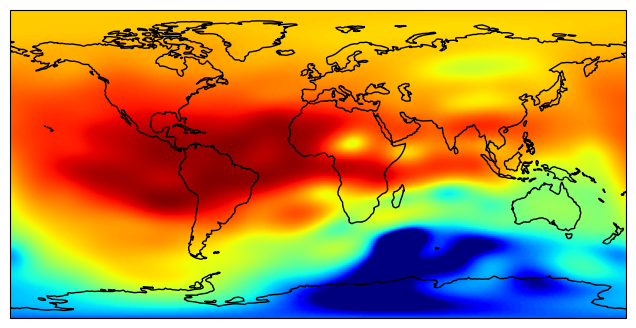

In [19]:
# Plot the TEC map
# Create a GeoAxes instance with a specific projection
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

im = ax.imshow(
    tec_map[0],
    extent=[-180, 180, -90, 90],
    origin='upper',
    cmap='jet',
    transform=ccrs.PlateCarree()
)

ax.coastlines()

plt.show()

## Sequence of multiple datasets setup
Example of setting up a sequence dataset for with the JPLD, OMNIWeb, and the SunMoon datasets

In [20]:
# Initialize variables
date_start = datetime.datetime(2024, 5, 9)
date_end = datetime.datetime(2024, 5, 10)
image_size = (180, 360)
context_window = 2 # Number of time steps of context used in model
prediction_window = 1 # Number of time steps to predict
training_sequence_length = context_window + prediction_window
delta_minutes = 15 # 15-minute cadence
date_dilation = 16 # Use 16x dilation for 15-min data to get 4-hour context

date_exclusions = []
datasets_omniweb_valid = []
datasets_jpld_valid = []
datasets_sunmoon_valid = []

dataset_omniweb_dir = 'data/omniweb/' #'/path/to/omniweb/data/'
dataset_jpld_dir = 'data/jpld' #'/path/to/jpld/data/'

# Create sequence dataset excluding validation events
dataset_jpld = JPLD(dataset_jpld_dir, date_start=date_start, date_end=date_end, date_exclusions=date_exclusions)
dataset_omniweb = OMNIWeb(dataset_omniweb_dir, date_start=date_start, date_end=date_end, date_exclusions=date_exclusions, return_as_image_size=image_size)
dataset_sunmoon = SunMoonGeometry(date_start=date_start, date_end=date_end, date_exclusions=date_exclusions)

# Create Sequence datasets
dataset = Sequences(datasets=[dataset_jpld, dataset_omniweb, dataset_sunmoon], sequence_length=training_sequence_length, dilation=date_dilation, delta_minutes=delta_minutes)



JPLD
Directory      : data/jpld
Rewind minutes : 50
Loading tar files index from cache: data/jpld/tar_files_index_d814fb9516ff8e99467e7ba2e04a2f2a
Start date : 2024-05-09 00:00:00
End date   : 2024-05-10 00:00:00
Delta      : 15 minutes
Date exclusions:


Filtering dates: 100%|██████████| 96/96 [00:00<00:00, 63250.58it/s]

Saving dates to cache: data/jpld/dates_index_2024-05-09T00:00:00_2024-05-10T00:00:00_4df58bd40b8a821dd5c2f09e3efd00eb
TEC maps total    : 96
TEC maps available: 96
TEC maps dropped  : 0

OMNIWeb
File indices           : data/omniweb/omniweb_indices_15min.csv
File magnetic field    : data/omniweb/omniweb_magnetic_field_15min.csv
File solar wind        : data/omniweb/omniweb_solar_wind_15min.csv


Data shape             : (498625, 15)
Data columns           : ['all__dates_datetime__', 'omniweb__ae_index__[nT]', 'omniweb__al_index__[nT]', 'omniweb__au_index__[nT]', 'omniweb__sym_d__[nT]', 'omniweb__sym_h__[nT]', 'omniweb__asy_d__[nT]', 'source__gaps_flag__', 'omniweb__bx_gse__[nT]', 'omniweb__by_gse__[nT]', 'omniweb__bz_gse__[nT]', 'omniweb__speed__[km/s]', 'omniweb__vx_velocity__[km/s]', 'omniweb__vy_velocity__[km/s]', 'omniweb__vz_velocity__[km/s]']
Delta minutes         : 15
Normalize             : True
Rewind minutes        : 50
Columns               : ['omniweb__ae_index__[nT]', 'omniweb__al_index__[nT]', 'omniweb__au_index__[nT]', 'omniweb__sym_d__[nT]', 'omniweb__sym_h__[nT]', 'omniweb__asy_d__[nT]', 'omniweb__bx_gse__[nT]', 'omniweb__by_gse__[nT]', 'omniweb__bz_gse__[nT]', 'omniweb__speed__[km/s]', 'omniweb__vx_velocity__[km/s]', 'omniweb__vy_velocity__[km/s]', 'omniweb__vz_velocity__[km/s]']
Return as image size  : (180, 360)
Rows before processing: 498,625
Date exclusio

## Train and Validation setup

Example of setting up a dataset for training and validation using the JPLD, OMNIWeb, and the SunMoon datasets, excluding certain events for validation.

In [21]:
# Initialize variables
date_start = datetime.datetime(2024, 5, 9)
date_end = datetime.datetime(2024, 5, 10)
image_size = (180, 360)
context_window = 2 # Number of time steps of context used in model
prediction_window = 1 # Number of time steps to predict
training_sequence_length = context_window + prediction_window
delta_minutes = 15 # 15-minute cadence
date_dilation = 16 # Use 16x dilation for 15-min data to get 4-hour context

dataset_omniweb_dir = 'data/omniweb/' #'/path/to/omniweb/data/'
dataset_jpld_dir = 'data/jpld' #'/path/to/jpld/data/'

# Make a EventCatalog[event_id], a dict with keys:
# 'date_start': date_start,
# 'date_end': date_end,
# 'duration': duration,
# 'max_kp': max_kp,
# 'time_steps': time_steps
event_id = "G5H3-202405101500"
event_start = datetime.datetime(2024, 5, 10, 15, 0).isoformat()
event_end = datetime.datetime(2024, 5, 10, 18, 0).isoformat()
duration = datetime.datetime.fromisoformat(event_end) - datetime.datetime.fromisoformat(event_start)
max_kp = 9.0
time_steps = int(duration.total_seconds() / (15*60))
catalog = {}
catalog[event_id] = {
  'date_start': event_start,
  'date_end': event_end,
  'duration': duration,
  'max_kp': max_kp,
  'time_steps': time_steps
}

event_catalog = EventCatalog(catalog=catalog)
valid_event_id = ["G5H3-202405101500"]

date_exclusions = []
datasets_omniweb_valid = []
datasets_jpld_valid = []
datasets_sunmoon_valid = []

# Process validation events
for event_id in valid_event_id:
    print('Excluding event ID: {}'.format(event_id))

    if event_id not in event_catalog:
        raise ValueError('Event ID {} not found in EventCatalog'.format(event_id))

    event = event_catalog[event_id]
    exclusion_start = datetime.datetime.fromisoformat(event['date_start']) - datetime.timedelta(minutes=context_window * delta_minutes)
    exclusion_end = datetime.datetime.fromisoformat(event['date_end'])
    date_exclusions.append((exclusion_start, exclusion_end))
    print('Exclusion start: {}, end: {}'.format(exclusion_start, exclusion_end))

    datasets_omniweb_valid.append(OMNIWeb(dataset_omniweb_dir, date_start=exclusion_start, date_end=exclusion_end, return_as_image_size=image_size))
    datasets_jpld_valid.append(JPLD(dataset_jpld_dir, date_start=exclusion_start, date_end=exclusion_end))
    datasets_sunmoon_valid.append(SunMoonGeometry(date_start=exclusion_start, date_end=exclusion_end))

# Create validation dataset
dataset_jpld_valid = Union(datasets=datasets_jpld_valid)
dataset_omniweb_valid = Union(datasets=datasets_omniweb_valid)
dataset_sunmoon_valid = Union(datasets=datasets_sunmoon_valid)

# Create training dataset excluding validation events
dataset_jpld_train = JPLD(dataset_jpld_dir, date_start=date_start, date_end=date_end, date_exclusions=date_exclusions)
dataset_omniweb_train = OMNIWeb(dataset_omniweb_dir, date_start=date_start, date_end=date_end, date_exclusions=date_exclusions, return_as_image_size=image_size)
dataset_sunmoon_train = SunMoonGeometry(date_start=date_start, date_end=date_end, date_exclusions=date_exclusions)

# Create Sequence datasets
dataset_valid = Sequences(datasets=[dataset_jpld_valid, dataset_omniweb_valid, dataset_sunmoon_valid], sequence_length=training_sequence_length, dilation=date_dilation, delta_minutes=delta_minutes)
dataset_train = Sequences(datasets=[dataset_jpld_train, dataset_omniweb_train, dataset_sunmoon_train], sequence_length=training_sequence_length, dilation=date_dilation, delta_minutes=delta_minutes)


Excluding event ID: G5H3-202405101500
Exclusion start: 2024-05-10 14:30:00, end: 2024-05-10 18:00:00

OMNIWeb
File indices           : data/omniweb/omniweb_indices_15min.csv
File magnetic field    : data/omniweb/omniweb_magnetic_field_15min.csv
File solar wind        : data/omniweb/omniweb_solar_wind_15min.csv
Data shape             : (498625, 15)
Data columns           : ['all__dates_datetime__', 'omniweb__ae_index__[nT]', 'omniweb__al_index__[nT]', 'omniweb__au_index__[nT]', 'omniweb__sym_d__[nT]', 'omniweb__sym_h__[nT]', 'omniweb__asy_d__[nT]', 'source__gaps_flag__', 'omniweb__bx_gse__[nT]', 'omniweb__by_gse__[nT]', 'omniweb__bz_gse__[nT]', 'omniweb__speed__[km/s]', 'omniweb__vx_velocity__[km/s]', 'omniweb__vy_velocity__[km/s]', 'omniweb__vz_velocity__[km/s]']
Delta minutes         : 15
Normalize             : True
Rewind minutes        : 50
Columns               : ['omniweb__ae_index__[nT]', 'omniweb__al_index__[nT]', 'omniweb__au_index__[nT]', 'omniweb__sym_d__[nT]', 'omniweb__sym

Filtering dates: 100%|██████████| 14/14 [00:00<00:00, 82356.60it/s]


Saving dates to cache: data/jpld/dates_index_2024-05-10T14:30:00_2024-05-10T18:00:00
TEC maps total    : 14
TEC maps available: 14
TEC maps dropped  : 0

Sun and Moon Geometry
Start date              : 2024-05-10 14:30:00
End date                : 2024-05-10 18:00:00
Delta                   : 15 minutes
Image size              : (180, 360)
Extra time steps        : 0

Union of datasets
Dataset : JPLD (2024-05-10 14:30:00 - 2024-05-10 18:00:00)

Union of datasets
Dataset : OMNIWeb (2024-05-10 14:30:00 - 2024-05-10 18:00:00)

Union of datasets
Dataset : SunMoonGeometry (2024-05-10 14:30:00 - 2024-05-10 18:00:00)

JPLD
Directory      : data/jpld
Rewind minutes : 50
Loading tar files index from cache: data/jpld/tar_files_index_d814fb9516ff8e99467e7ba2e04a2f2a
Start date : 2024-05-09 00:00:00
End date   : 2024-05-10 00:00:00
Delta      : 15 minutes
Date exclusions:
  2024-05-10 14:30:00 - 2024-05-10 18:00:00


Filtering dates: 100%|██████████| 96/96 [00:00<00:00, 126026.04it/s]

Saving dates to cache: data/jpld/dates_index_2024-05-09T00:00:00_2024-05-10T00:00:00_087c0d11480ed0af6f9f5c1806b7fe22
TEC maps total    : 96
TEC maps available: 96
TEC maps dropped  : 0

OMNIWeb
File indices           : data/omniweb/omniweb_indices_15min.csv
File magnetic field    : data/omniweb/omniweb_magnetic_field_15min.csv
File solar wind        : data/omniweb/omniweb_solar_wind_15min.csv


Data shape             : (498625, 15)
Data columns           : ['all__dates_datetime__', 'omniweb__ae_index__[nT]', 'omniweb__al_index__[nT]', 'omniweb__au_index__[nT]', 'omniweb__sym_d__[nT]', 'omniweb__sym_h__[nT]', 'omniweb__asy_d__[nT]', 'source__gaps_flag__', 'omniweb__bx_gse__[nT]', 'omniweb__by_gse__[nT]', 'omniweb__bz_gse__[nT]', 'omniweb__speed__[km/s]', 'omniweb__vx_velocity__[km/s]', 'omniweb__vy_velocity__[km/s]', 'omniweb__vz_velocity__[km/s]']
Delta minutes         : 15
Normalize             : True
Rewind minutes        : 50
Columns               : ['omniweb__ae_index__[nT]', 'omniweb__al_index__[nT]', 'omniweb__au_index__[nT]', 'omniweb__sym_d__[nT]', 'omniweb__sym_h__[nT]', 'omniweb__asy_d__[nT]', 'omniweb__bx_gse__[nT]', 'omniweb__by_gse__[nT]', 'omniweb__bz_gse__[nT]', 'omniweb__speed__[km/s]', 'omniweb__vx_velocity__[km/s]', 'omniweb__vy_velocity__[km/s]', 'omniweb__vz_velocity__[km/s]']
Return as image size  : (180, 360)
Rows before processing: 498,625
Date exclusio